#**Assignment 2: CNNs** (***Due date: October 2, 2025***)
## Overview
## Total [100 Points + 10 Bonus]
In this assignment, you will implement a Convolutional Neural Network (CNN) to classify images from a flower recognition dataset containing 5 different types of flowers: Daisy, Dandelion, Rose, Sunflower, and Tulip. You'll first build a CNN from scratch to understand the fundamental components, then build the training loop for the model.


### Submission:
You will need to submit the following to Canvas:
  

1.   your notebook.ipynb
2.   your model.pth file




# Setting up

We'll start by importing some dependancies, the following are the most important:
- [`torch`](https://pytorch.org/docs/stable/torch.html) - the core PyTorch library.
- [`torch.nn`](https://pytorch.org/docs/stable/nn.html) - a module containing building blocks for NNs such as linear layers, convolutional layers, and so on.
- [`torch.optim`](https://pytorch.org/docs/stable/optim.html) - a module containing optimizers which update the parameters of a NN.
- [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) in [`torch.utils.data`](https://pytorch.org/docs/stable/data.html) - Can be used to batch data together and iterate over batches, shuffle data, and parallelize the training process to speed it up.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data
- Number of classes: 5 (Daisy, Dandelion, Rose, Sunflower, Tulip)
- Total images: ~2,700
- Image format: RGB images in JPG format
- Image dimensions: Variable (will need to be resized)
- Dataset structure:
```
flowers-dataset/train/
├── daisy/
├── dandelion/
├── rose/
├── sunflower/
└── tulip/
```

**Important Note!**

You will have access to 95% of the data only for your training and validation.

In real life scenarios your data should typically be divided into 3 splits: training, validation, and test.
- The training part would be the majority of your data and will be what you train your model on
- The validation split should be used to optimize your model to make sure it generlizes well to unseen data
- The test set should be used only once to report the performance of your model and you shouldn't try to retrain your model to get a better result, because if you did you could be biasing your model to perform well on that data and it will not serve as an accurate measure of how well your model performs on unseen data

To simulate this behaviour the remaining 5% of the data is kept by us as a test set to be used to evaluate your final models.

## Pre-processing

We'll need to define transformations that are applied to our data automatically. Data transforms are crucial for:
- Standardizing input sizes (224x224 is common for many architectures)
- Data augmentation to prevent overfitting
- Normalizing pixel values to help with training stability

We'll first resize and crop that data to a standard size. Notice how validation has a deterministic crop, unlike how training has a random crop.

after that, we cast the images to PyTorch tensors using [`transforms.ToTensor()`](https://pytorch.org/vision/master/generated/torchvision.transforms.ToTensor.html). These tensors are automatically normalized such that their values are between 0 and 1.

Then, we'll re-normalize the pixel values with [`transforms.Normalize()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html) to conform a to a distribution empirically determined from ImageNet, which is a large image dataset. This has been shown empirically to improve training stability

In [2]:
# Define data transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

We can know load our downloaded dataset
- `ImageFolder` automatically handles class labels from directory structure
- `DataLoader` handles batching and shuffling

We'll use a (mini) batch size of 32. It's common to use powers of 2 in deep learning because it's more efficient to handle such numbers on hardware.

We'll define separate `DataLoader` objects to handle our training and test splits to avoid data leakage (training on the test set or testing on the train set).

We'll also have the `DataLoader` objects shuffle our data whenever we iterate over them (`shuffle=True`). Shuffling data at each epoch is beneficial in that the model won't be optimized in a way that depends on a specific ordering of the data. From a more theoritical point of view, this is our way of maintaining the independant and identically distributed (iid) assumbtion

In [3]:
# Load the datasets
data_dir = '/content/drive/Shareddrives/COSC_3470_Fall25/datasets/flowers_dataset/'  # Make sure to mount the drive
dataset = ImageFolder(data_dir, transform=None)
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Create train/validation splits
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=1)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=1)

# Print dataset information
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of training samples: 2088
Number of validation samples: 523
Number of classes: 5


In [4]:
# To check the size of a training batch you can run this cell
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Model
### Part 1: model architecture [30 points]
Now you will implement your own CNN model to be trained on the data. In general, a PyTorch neural network definition must:
- subclass [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)
- call `super().__init__()` in the constructor (`__init__()`) method
- define the trainable parameters/layers (convolutions, linears, poolings, etc.) in the constructor
- define what should happen to the inputs in the `forward()` method

Hints:
- Start with a simple architecture and gradually add complexity
- Print tensor shapes to debug dimension mismatches
- Consider how each layer affects the feature map size
- Remember: (N, C, H, W) is PyTorch's tensor format
- Don't lose hope, it can be frustrating to train your first model, just keep trying. You should get there eventually.

In [5]:
class FlowerCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(FlowerCNN, self).__init__()

        # TODO: Implement the CNN architecture
        # Hint: Consider the following structure:
        # 1. Multiple convolutional blocks (conv -> relu -> pooling)
        # 2. Increasing number of filters (e.g., 64 -> 128 -> 256 -> 512)
        # 3. Final fully connected layers

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            #3 to 64
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 112x112
            #64 to 128
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 56x56
            #128 to 256
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 28x28
            #256 to 512
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 14x14
            #512 to 512
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(1024, num_classes)
            # Add your fully connected layers here
            # Don't forget dropout for regularization
            # Calculate the correct input size for the first FC layer
        )

    def forward(self, x):
        # TODO: Implement the forward pass
        # Remember to flatten the tensor between conv and fc layers
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)  # flatten all but batch dim
        x = self.fc_layers(x)
        return x

# Initialize the model
model = FlowerCNN().to(device)

# Training
### Part 2: Training loop [30 points]
Now comes the fun part. You will train the model you just implemented on the flower dataset. Remember, it's an iterative apporach. It's normal to train a model, get some results, come back to your model implementation to modify it again, go back to train it again and (hopefully) get a better (or worse `¯\_(ツ)_/¯`) result.

To make things easier we already defined the loss and the optimizer for you.
- Since this is a multi-classification task, we will use [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html), a common loss function used to train classification models.
- For the optimizer, you can take a look at [`Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) Optimizer. You can try other optimizers too!

### Part 3: Training results [20 points + 10 bonus points]
You will be graded on this part based on your results on both the validation set you are using and the hidden test set.
- 10 points for getting an accuracy >= 60% on the validation set
- 10 points for getting an accuracy >= 60% on the held-out test set
- 10 bonus points for the top 3 performers on the held-out test set

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # TODO: Implement the training step, this is the general structure
            # 1. Move data to device
            inputs, labels = inputs.to(device), labels.to(device)
            # 2. Zero gradients
            optimizer.zero_grad()
            # 3. Forward pass
            outputs = model(inputs)
            # 4. Calculate loss
            loss = criterion(outputs, labels)
            # 5. Backward pass
            loss.backward()
            # 6. Update weights
            optimizer.step()
            # 7. Increment the running loss
            running_loss += loss.item() * inputs.size(0)  # sum loss over batch
        # TODO: Calculate epoch statistics (average loss over the epoch)
        # Track training loss and validation accuracy
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation phase
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {epoch_loss:.4f}')
        print(f'Validation Accuracy: {val_acc:.2f}%')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')

    return train_losses, val_accuracies

# Training parameters
# TODO: set the criterion and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Train the model
train_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer)

Epoch 1/5: 100%|██████████| 66/66 [00:27<00:00,  2.38it/s]


Epoch 1/5:
Training Loss: 0.3509
Validation Accuracy: 67.30%


Epoch 2/5: 100%|██████████| 66/66 [00:28<00:00,  2.34it/s]


Epoch 2/5:
Training Loss: 0.2708
Validation Accuracy: 65.39%


Epoch 3/5: 100%|██████████| 66/66 [00:27<00:00,  2.38it/s]


Epoch 3/5:
Training Loss: 0.2324
Validation Accuracy: 66.16%


Epoch 4/5: 100%|██████████| 66/66 [00:29<00:00,  2.26it/s]


Epoch 4/5:
Training Loss: 0.2226
Validation Accuracy: 65.58%


Epoch 5/5: 100%|██████████| 66/66 [00:27<00:00,  2.40it/s]


Epoch 5/5:
Training Loss: 0.1943
Validation Accuracy: 65.77%


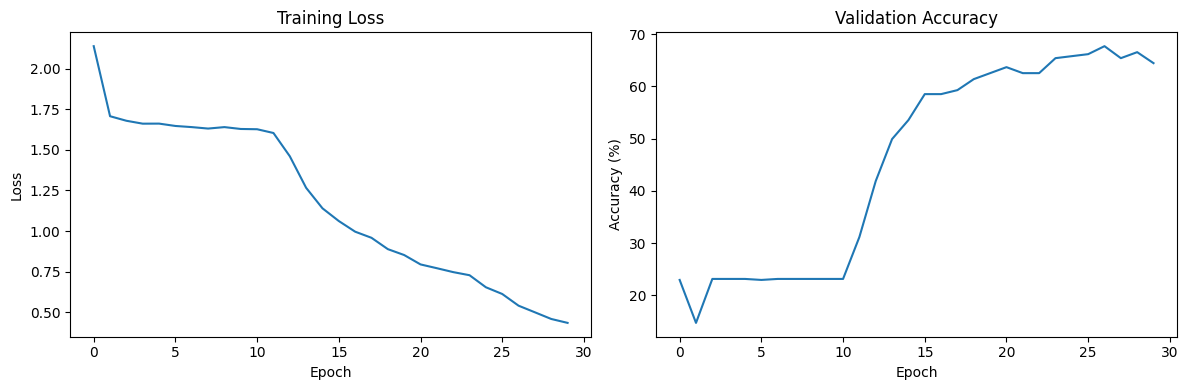

In [7]:
# You can use this to plot a graph of your training over time
# It can be useful to check if your model overfits or underfits the data
def plot_training_results(train_losses, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot training loss
    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')

    # Plot validation accuracy
    ax2.plot(val_accuracies)
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.show()

# Plot the results
plot_training_results(train_losses, val_accuracies)

## Model saving
This block is there to help you save your final model after training to be submitted with your notebook. This model will be used to evaluate your results on the test set.

Note: Don't remove the output of your training loop.

In [9]:
# Save the model
final_model = torch.jit.script(model)
final_model.save('final_model.pth')

In [11]:
# Load and test the model
from PIL import Image
model = torch.jit.load("final_model.pth")
model.eval()

# Try on a sample patch (to make sure yor model is saved correctely)
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        print(predicted)
        break

tensor([3, 2, 2, 0, 0, 2, 3, 3, 0, 4, 1, 4, 3, 4, 0, 4, 2, 0, 2, 0, 4, 3, 1, 3,
        2, 4, 1, 2, 3, 0, 0, 3], device='cuda:0')


# Conceptual Short Answer Questions

### Part 1: [10 points]

1.   What is the receptive field in CNNs?
2.   Explain max pooling vs. average pooling and their impact on feature extraction.
3. Why CNNs are more efficient than FC NNs?
4. What is dropout, and how does it prevent overfitting?
5. Why do we use data augmentation during training but not during validation?




Part 1 Answers
1. The receptive field in CNNs is the region of the input image that affects that neuron’s activation. As we traverse deeper into the network, the receptive field increases as each neuron is influenced by a larger portion of the input as a result of successive convolutions and pooling layers
2. Max pooling takes the maximum value in each patch while average pooling takes the average of all values in each patch. As such, max pooling takes on the more dominant features which leads to sparser and more discriminative features. On the other hand, average pooling having taking the average, smoothens the features and produces less sensitive features but still preserving the overall trend. Therefore, max pooling is preferred when it comes to classification tasks.
3. CNNs uses local connectivity and shares their weights, while FC NNs requires every neuron to be connected to every input. This results in FC NNs being extremely computationally expensive as the network grows with more parameters and input size. However, CNNs are more efficient as it requires much fewer parameters due to its ability to share weights while maintaining spatial hierarchy.
4. Dropout is a regularization technique that randomly selects neurons to be "dropped", or set to 0, during training. As such, the network cannot rely on specific neurons and hence "forced" to learn redundant and robust features. Overfitting is the notion of the model essentially "memorising" the training data such that it fails to generalise to unseen test cases. Hence, with dropout, it reduces co-adaptation among neurons and generalises better on new test cases.
5. Data augmentation refers to the idea of creating synthetic variations of training images to make the model more robust. The goal is for the model to learn invariance to such transformations and translations. However, we do not use it during validation as we want to measure the performance of the network on real, unmodified data for better generalisation when it is exposed to the test cases.

## Computing Output Size and Number of Parameters in a CNN Block  
### Part 2: [10 points]
Consider a **CNN block** that consists of the following layers applied sequentially to an input image of size **(224 × 224 × 3) (Height × Width × Channels):**  

1. **Convolutional Layer**:  
   - **32 filters** of size **(3 × 3 x 3)**  
  - **Stride = 2**, **Padding = 1**  

2. **Max Pooling Layer**:  
   - Pool size **(2 × 2)**  
   - **Stride = 2**  , **Padding = 0**

3. **Another Convolutional Layer**:  
   - **64 filters of size (3 × 3 x C) (C is the number of chanels)**
   - **Stride = 1**, **Padding = 1**  

---
**(a) Compute the output size after each layer in the CNN block.**

**(b) Compute the total number of trainable parameters in the CNN layers.**
   - Assume each convolutional layer has a **bias term for each filter**.  

---

### **Hints:**
- The output size of a **convolutional layer** is given by:  
  $$
  H_{\text{out}} = \frac{H_{\text{in}} - K + 2P}{S} + 1
  $$

  where:  
  - ($H_{\text{in}}$) is input height,  
  - \( K \) is kernel size,  
  - \( P \) is padding,  
  - \( S \) is stride.  

- The number of parameters in a convolutional layer is:  
  $
  (\text{filter height} \times \text{filter width} \times \text{input channels} + 1) \times \text{number of filters}
  $
  (The **+1** accounts for the bias term per filter).

- In practice, frameworks floor the division (e.g., ⌊111/2⌋ = 55)


Part 2 Answers:<br>
(a) Compute the output size after each layer in the CNN block.<br>
<br>
First layer: floor((224-3+2(1))/2)+1=112<br>
Max Pool 1: floor((112-2+0)/2)+1=56<br>
Second layer: floor((56-3+2(1))/1)+1=56<br>
<br>
(b) Compute the total number of trainable parameters in the CNN layers.<br>
<br>
First layer: (3x3x3+1)x(32)=896<br>
Second layer: (3x3x32+1)x(64)=18496<br>
Total: 896+18496=19392<br>
